# 17 - theme conviction vs an ETF OF YOUR CHOICE

Notebook 14 draws each theme against its DEFAULT anchor ETF. This notebook
lets you pick the pairing yourself: any theme from the conviction file
against any symbol the price puller covers (the availability cell below
lists exactly what you can choose from).

Typical uses: semiconductors against SOXX instead of SMH, a theme against a
single stock proxy, or the same theme against two ETFs to compare.

Edit CHOICES in the parameters cell, then run all.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py) win; otherwise the
# constants at the top of update_data.py. Same toggle as live vs backtest.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)

import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2020-01-08 -> 2025-02-28


In [2]:
# ==== AVAILABILITY: what you can choose from ====
from src.themes import THEME_ETFS, THEME_ETF_FALLBACKS

conv_all = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv_all['date'] = pd.to_datetime(conv_all['date'])
conv = clip_dates(conv_all, 'date')

prices_all = load_prices()
priced = set(prices_all['symbol'])

themes_avail = sorted(conv['theme'].unique())
print(f'{len(themes_avail)} themes with conviction data in this window')
print(f'{len(priced)} symbols with price data (any of these is a valid ETF choice)')
print()
print(f"{'theme':<24} {'default anchor':<15} fallbacks")
for t in themes_avail:
    a = THEME_ETFS.get(t, '-')
    mark = '' if a in priced else '  (anchor NOT priced in window)'
    fb = ', '.join(THEME_ETF_FALLBACKS.get(t, [])) or '-'
    print(f'{t:<24} {a:<15} {fb}{mark}')

39 themes with conviction data in this window
322 symbols with price data (any of these is a valid ETF choice)

theme                    default anchor  fallbacks
agriculture_food         MOO             -
ai                       AIQ             AIQ, BOTZ, QQQ
ai_megacap               MAGS            MAGS, QQQ
biotech_pharma           XBI             -
cannabis                 MSOS            MSOS, TLRY
china_geopolitics        KWEB            -
cloud_saas               IGV             -
consumer_retail          XLY             -
crypto                   IBIT            IBIT, BITO, GBTC
cybersecurity            CIBR            -
datacenters              DTCR            DTCR, SRVR, EQIX
defense_aerospace        ITA             -
energy                   XLE             -
europe_defense           EUAD            EUAD, ITA
ev_clean_energy          ICLN            -
financials               XLF             -
fintech_payments         IPAY            -
gaming_esports           ESPO         

In [3]:
# ==================== EDIT THIS ====================
# theme -> ETF/symbol to draw it against.
#   None = use the theme's default anchor (with fallbacks if unpriced).
#   Any symbol from the availability list above is valid - a theme can
#   appear against a non-default ETF, e.g. semiconductors vs SOXX.
CHOICES = {
    'semiconductors': 'SOXX',
    'gold': 'GLD',
}

CROSS_AT = 1.5    # conviction crossings marked at +/- this z level
MIN_GAP  = 10     # days between counted crossings
X_TICKS  = 'auto' # 'auto' | 'W' | 'M'
# ===================================================

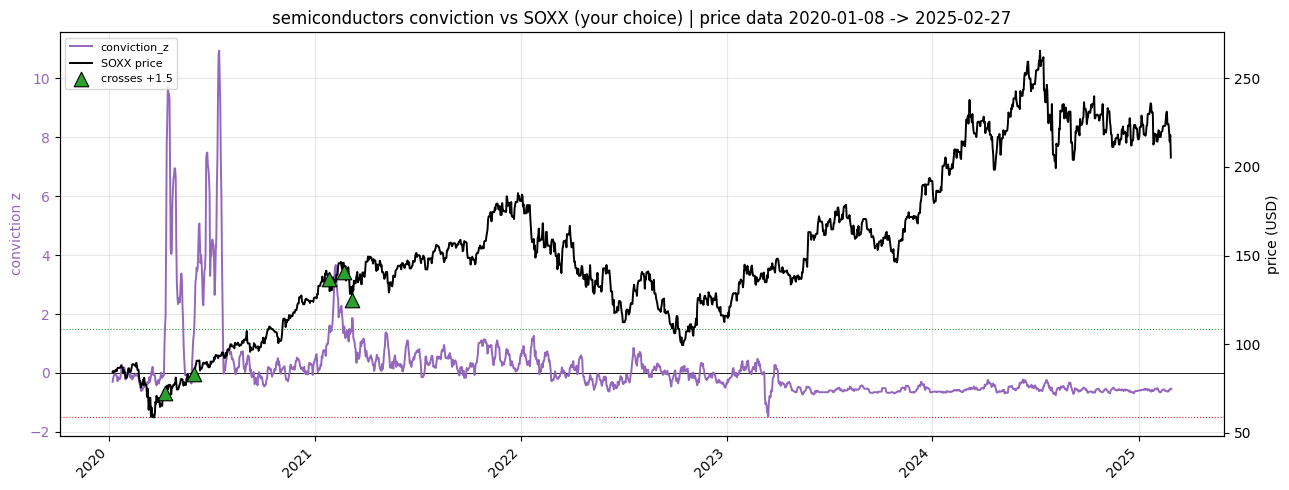

gold: NO CONVICTION DATA in this window (run notebook 09 / --full first)


In [4]:
# ==== CUSTOM THEME-vs-ETF CONVICTION OVERLAYS ====
def resolve_symbol(theme, override):
    # the override wins if priced; otherwise the default anchor, then its
    # fallbacks, until something has price data in this window
    candidates = []
    if override:
        candidates.append(override)
    if THEME_ETFS.get(theme):
        candidates.append(THEME_ETFS[theme])
    candidates += THEME_ETF_FALLBACKS.get(theme, [])
    for sym in candidates:
        if sym in priced and not price_series(prices_all, sym).empty:
            return sym, (sym != override and override is not None)
    return None, False

def spaced(idx, gap):
    out = []
    for d in idx:
        if not out or (d - out[-1]).days >= gap:
            out.append(d)
    return out

for theme, override in CHOICES.items():
    cz = (conv[conv['theme'] == theme].sort_values('date')
          .set_index('date')['conviction_z'].asfreq('D').ffill())
    if cz.empty:
        print(f'{theme}: NO CONVICTION DATA in this window (run notebook 09 / --full first)')
        continue
    sym, fell_back = resolve_symbol(theme, override)
    if sym is None:
        print(f'{theme}: neither the chosen symbol nor any fallback has price data here')
        continue
    if fell_back:
        print(f'{theme}: chosen symbol {override} has no price data in this window - using {sym}')
    px = price_series(prices_all, sym)

    up = spaced(cz[(cz > CROSS_AT) & (cz.shift(1) <= CROSS_AT)].index, MIN_GAP)
    down = spaced(cz[(cz < -CROSS_AT) & (cz.shift(1) >= -CROSS_AT)].index, MIN_GAP)

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.axhline(0, color='black', linewidth=0.6)
    ax1.axhline(CROSS_AT, color='tab:green', linestyle=':', linewidth=0.8)
    ax1.axhline(-CROSS_AT, color='tab:red', linestyle=':', linewidth=0.8)
    ax1.plot(cz.index, cz.values, color='tab:purple', linewidth=1.4, label='conviction_z')
    ax1.set_ylabel('conviction z', color='tab:purple')
    ax1.tick_params(axis='y', labelcolor='tab:purple')

    ax2 = ax1.twinx()
    ax2.plot(px.index, px.values, color='black', linewidth=1.4, label=f'{sym} price')
    ax2.set_ylabel('price (USD)')
    for i, d in enumerate(up):
        pa = px.asof(d)
        if pd.notna(pa):
            ax2.scatter([d], [pa], marker='^', s=110, color='tab:green',
                        edgecolors='black', linewidths=0.8, zorder=5,
                        label=f'crosses +{CROSS_AT}' if i == 0 else None)
    for i, d in enumerate(down):
        pa = px.asof(d)
        if pd.notna(pa):
            ax2.scatter([d], [pa], marker='v', s=110, color='tab:red',
                        edgecolors='black', linewidths=0.8, zorder=5,
                        label=f'crosses -{CROSS_AT}' if i == 0 else None)

    note = '' if px.empty else f' | price data {px.index.min().date()} -> {px.index.max().date()}'
    ax1.set_title(f'{theme} conviction vs {sym}'
                  + (f' (your choice)' if override == sym else '') + note)
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    set_date_ticks(ax1, X_TICKS)
    fig.tight_layout(); plt.show()